In [160]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

In [161]:
x = sp.symbols('x')
func = x*sp.sqrt(x)
a = 0
b = 4
n = 10

In [162]:
# Вузли Чебишева на [-1, 1]
i = np.arange(n)
x_cheb = -np.cos((2 * i + 1) * np.pi / (2 * n))

# Масштабування до [a, b]
t_i = (a + b)/2 + (b - a)/2 * x_cheb

# Обчислення значень функції в вузлах
f_vals = np.round(t_i * np.sqrt(t_i), 6)  # f(x) = x * sqrt(x) = x^(3/2)

# Формування таблиці
chebyshev_nodes = pd.DataFrame({
    "i": i,
    "x_i (на [-1,1])": np.round(x_cheb, 4),
    "t_i (на [0,4])": np.round(t_i, 6),
    "f(t_i)": f_vals
})

chebyshev_nodes

,i,"x_i (на [-1,1])","t_i (на [0,4])",f(t_i)
0,0,-0.9877,0.024623,0.003864
1,1,-0.8910,0.217987,0.101776
2,2,-0.7071,0.585786,0.448342
3,3,-0.4540,1.092019,1.141157
4,4,-0.1564,1.687131,2.191408
5,5,0.1564,2.312869,3.517439
6,6,0.4540,2.907981,4.958923
7,7,0.7071,3.414214,6.308644
8,8,0.8910,3.782013,7.355031
9,9,0.9877,3.975377,7.926244


In [163]:
y = f_vals

In [ ]:
x = sp.Symbol('x')

n = len(t_i)
lagrange_poly = 0

for j in range(n):
    # Обчислюємо базисний поліном l_j(x)
    l_j = 1
    for i in range(n):
        if i != j:
            l_j *= (x - t_i[i]) / (t_i[j] - t_i[i])
    lagrange_poly += f_vals[j] * l_j

lagrange_poly = sp.simplify(lagrange_poly)
lagrange_poly

-0.000166535689867161*x**9 + 0.00338793308705031*x**8 - 0.0294952634383512*x**7 + 0.143804880933915*x**6 - 0.43258318799814*x**5 + 0.840610392933202*x**4 - 1.11018560401845*x**3 + 1.36037104338868*x**2 + 0.226918530300744*x - 0.00253202175588988

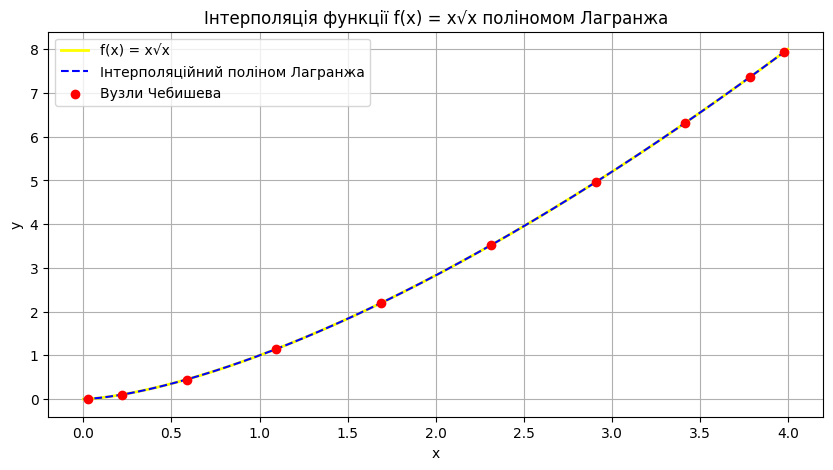

In [165]:
# Перетворюємо sympy-вираз у функцію
f_interp = sp.lambdify(x, lagrange_poly, modules=['numpy'])

# Побудова графіка
x_plot = np.linspace(0, 4, 500)
y_interp = f_interp(x_plot)
y_real = x_plot * np.sqrt(x_plot)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_real, label='f(x) = x√x', color='yellow', linewidth=2)
plt.plot(x_plot, y_interp, label='Інтерполяційний поліном Лагранжа', linestyle='--', color='blue')
plt.scatter(t_i, f_vals, color='red', zorder=5, label='Вузли Чебишева')
plt.legend()
plt.grid(True)
plt.title("Інтерполяція функції f(x) = x√x поліномом Лагранжа")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [166]:
def progonka(A, bb):
    n = len(bb)
    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    alpha = np.zeros(n)
    beta = np.zeros(n)
    xout = np.zeros(n)

    # Збирання трьох діагоналей
    for i in range(1, n - 1):
        a[i] = A[i][i - 1]
        b[i] = A[i][i]
        c[i] = A[i][i + 1]
    b[0] = A[0][0]
    b[-1] = A[-1][-1]

    # Прямий хід
    alpha[1] = -c[0] / b[0]
    beta[1] = bb[0] / b[0]

    for i in range(1, n - 1):
        denom = b[i] + a[i] * alpha[i]
        alpha[i + 1] = -c[i] / denom
        beta[i + 1] = (bb[i] - a[i] * beta[i]) / denom

    # Зворотній хід
    xout[-1] = (bb[-1] - a[-1] * beta[-1]) / (b[-1] + a[-1] * alpha[-1])
    for i in range(n - 2, -1, -1):
        xout[i] = alpha[i + 1] * xout[i + 1] + beta[i + 1]

    return xout


In [167]:
def cubic_spline_scheme(x, y):
    n = len(x)
    h = np.diff(x)
    AA = np.zeros((n, n))
    bb = np.zeros(n)
    a = np.zeros(n)
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)

    a[:] = y

    # Крайові умови 
    AA[0][0] = 1
    AA[-1][-1] = 1
    bb[0] = 0
    bb[-1] = 0
    
    # Формування системи
    for i in range(1, n - 1):
        AA[i][i - 1] = h[i - 1]
        AA[i][i] = 2 * (h[i - 1] + h[i])
        AA[i][i + 1] = h[i]
        bb[i] = 3 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])

    # Розв'язання
    c = progonka(AA, bb)

    # b, d
    for i in range(n - 1):
        d[i] = (c[i + 1] - c[i]) / (3 * h[i])
        b[i] = ((y[i + 1] - y[i]) / h[i]
                - h[i] * (2 * c[i] + c[i + 1]) / 3)

    return a[:-1], b[:-1], c[:-1], d[:-1]


In [168]:
y = f_vals
x = t_i

In [169]:
a_, b_, c_, d_ = cubic_spline_scheme(x, y)

In [170]:
x_sym = sp.Symbol('x')
polynomials = []

for i in range(len(a_)):
    dx = x_sym - x[i]  # зміщення від вузла xᵢ
    Si = a_[i] + b_[i]*dx + c_[i]*dx**2 + d_[i]*dx**3
    Si = sp.simplify(Si.expand())  
    polynomials.append(Si)

# Вивід усіх поліномів
for i, poly in enumerate(polynomials):
    print(f"S_{i}(x) на [{x[i]:.4f}, {x[i+1]:.4f}]:")
    print(poly)
    print()

S_0(x) на [0.0246, 0.2180]:
1.77843945369564*x**3 - 0.131373244956419*x**2 + 0.443101914650694*x - 0.00699353795833322

S_1(x) на [0.2180, 0.5858]:
-0.565699432031461*x**3 + 1.4016018246872*x**2 + 0.108933352304621*x + 0.0172879241197165

S_2(x) на [0.5858, 1.0920]:
-0.02482230486997*x**3 + 0.451086368145782*x**2 + 0.665732415501326*x - 0.0914338557816155

S_3(x) на [1.0920, 1.6871]:
-0.0490670463128162*x**3 + 0.530513523100697*x**2 + 0.578996453133242*x - 0.0598614161368107

S_4(x) на [1.6871, 2.3129]:
-0.0191733348964221*x**3 + 0.379209695123276*x**2 + 0.834265842311709*x - 0.203419055364269

S_5(x) на [2.3129, 2.9080]:
-0.0140896304918029*x**3 + 0.343935869221805*x**2 + 0.915849578284288*x - 0.266316551407891

S_6(x) на [2.9080, 3.4142]:
-0.0171939871850208*x**3 + 0.371018100060255*x**2 + 0.837094965582571*x - 0.189977578955247

S_7(x) на [3.4142, 3.7820]:
0.0297543217008648*x**3 - 0.10985655872576*x**2 + 2.47890374741132*x - 2.05847284886957

S_8(x) на [3.7820, 3.9754]:
-0.39258871

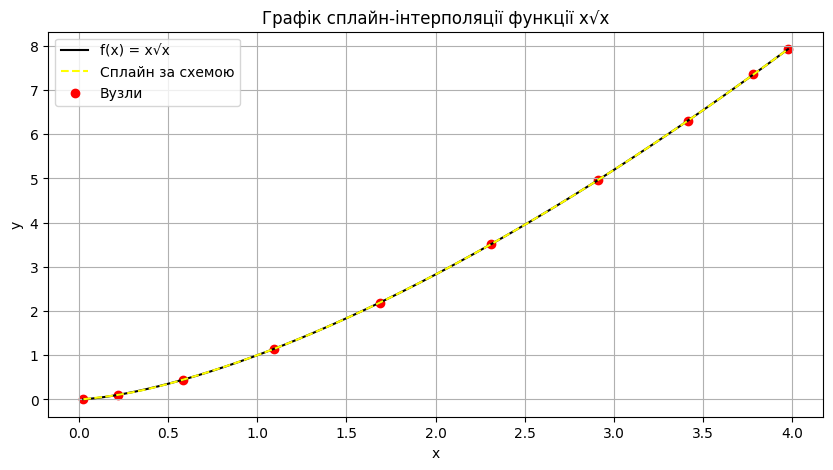

In [171]:
# a_, b_, c_, d_, x — результат cubic_spline_scheme

x_dense = np.linspace(x[0], x[-1], 1000)
y_spline = np.zeros_like(x_dense)

# Обчислюємо значення сплайна на кожному інтервалі
for i in range(len(a_)):
    mask = (x_dense >= x[i]) & (x_dense <= x[i + 1])
    dx = x_dense[mask] - x[i] 
    y_spline[mask] = (
        a_[i]
        + b_[i] * dx
        + c_[i] * dx**2
        + d_[i] * dx**3
    )

# Побудова оригінальної функції для порівняння
y_exact = x_dense * np.sqrt(x_dense)

# Побудова графіка
plt.figure(figsize=(10, 5))
plt.plot(x_dense, y_exact, label='f(x) = x√x', color='black')
plt.plot(x_dense, y_spline, '--', label='Сплайн за схемою', color='yellow')
plt.scatter(x, x * np.sqrt(x), color='red', label='Вузли')
plt.grid(True)
plt.legend()
plt.title("Графік сплайн-інтерполяції функції x√x")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

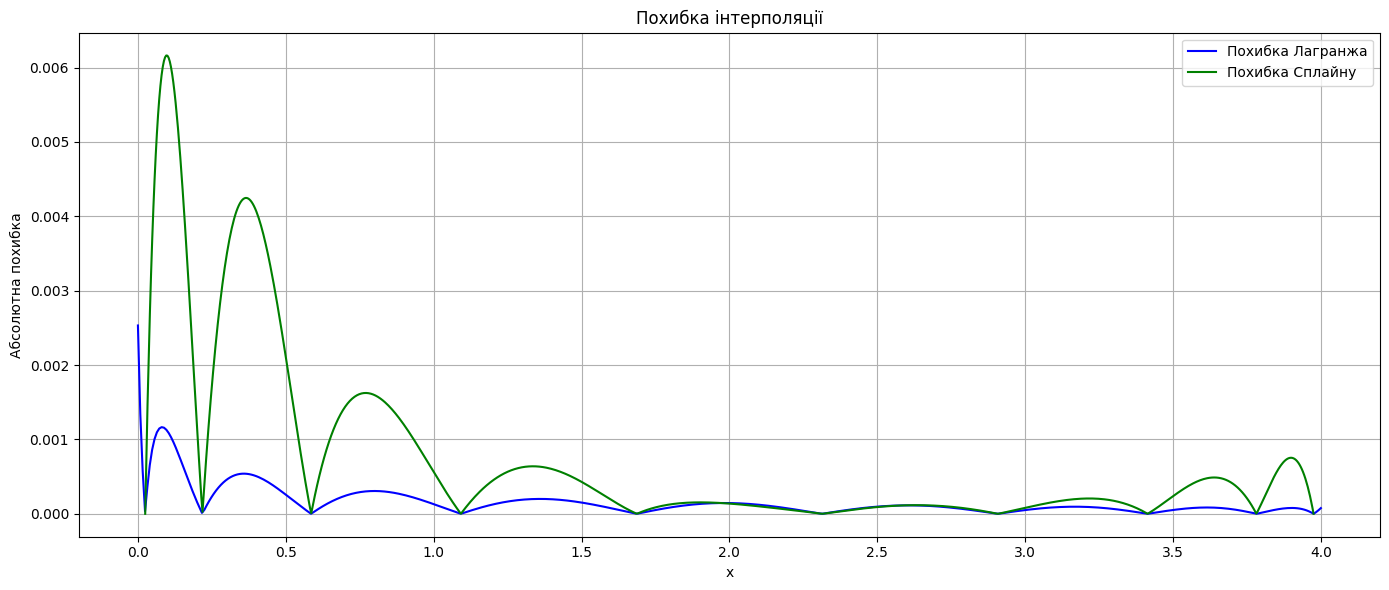

In [172]:
plt.figure(figsize=(14, 6))
# === Обчислення похибок
err_lagr = np.abs(y_interp - x_plot * np.sqrt(x_plot))
err_spline = np.abs(y_spline - y_exact)

# === Побудова графіка похибок
plt.plot(x_plot, err_lagr, 'b-', label='Похибка Лагранжа')
plt.plot(x_dense, err_spline, 'g-', label='Похибка Сплайну')
plt.title("Похибка інтерполяції")
plt.xlabel("x")
plt.ylabel("Абсолютна похибка")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()